## Notebook Overview (Authentication Logs)

This notebook builds an unsupervised anomaly detector for LANL authentication events.

What it does:
- Downloads `auth.txt.gz` and `redteam.txt.gz`.
- Parses authentication records for days 6, 7, and 8.
- Labels events as attack (`is_anomaly = 1`) using red-team ground truth keys.
- Trains a Transformer using masked-token prediction on day 7 data.
- Scores day 8 events and evaluates anomaly detection quality.

In [1]:
import os
import subprocess
import warnings
import gzip
import pandas as pd
import numpy as np
import gc
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

data_dir = './lanl_data'
model_dir = './saved_models'
os.makedirs(data_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

auth_file = os.path.join(data_dir, 'auth.txt.gz')
redteam_file = os.path.join(data_dir, 'redteam.txt.gz')

print("Installing aria2 for multi-threaded downloading...")
!DEBIAN_FRONTEND=noninteractive apt-get update -y > /dev/null 2>&1
!DEBIAN_FRONTEND=noninteractive apt-get install -y aria2 > /dev/null 2>&1

urls = {
    "redteam.txt.gz": "https://csr.lanl.gov/data-fence/1777876381/9usaCBU9obsPKD3bNQBQBzyXrI8=/cyber1/redteam.txt.gz",
    "auth.txt.gz": "https://csr.lanl.gov/data-fence/1777876381/9usaCBU9obsPKD3bNQBQBzyXrI8=/cyber1/auth.txt.gz"
}

print("\n--- Starting Downloads ---")
for filename, url in urls.items():
    dest_path = os.path.join(data_dir, filename)
    if os.path.exists(dest_path) and os.path.getsize(dest_path) > 1024:
        print(f"Skipping {filename}, already downloaded.")
        continue
        
    print(f"Downloading {filename}...")
    cmd = ["aria2c", "-x", "16", "-s", "16", "-k", "1M", "--dir", data_dir, "--out", filename, url]
    subprocess.run(cmd)

print("\nAll downloads processed!")

Installing aria2 for multi-threaded downloading...

--- Starting Downloads ---

05/05 00:08:42 [NOTICE] Downloading 1 item(s)

05/05 00:08:42 [NOTICE] Download complete: ./lanl_data/redteam.txt.gz

Download Results:
gid   |stat|avg speed  |path/URI
======+====+===========+=======================================================
13130b|OK  |   676KiB/s|./lanl_data/redteam.txt.gz

Status Legend:
(OK):download completed.

05/05 00:08:42 [NOTICE] Downloading 1 item(s)
[#7f53cd 16KiB/7.1GiB(0%) CN:16 DL:311KiB ETA:6h38m45s]
[#7f53cd 7.3MiB/7.1GiB(0%) CN:16 DL:6.8MiB ETA:17m47s]
[#7f53cd 19MiB/7.1GiB(0%) CN:16 DL:9.2MiB ETA:13m1s]
[#7f53cd 36MiB/7.1GiB(0%) CN:16 DL:12MiB ETA:10m1s]
[#7f53cd 54MiB/7.1GiB(0%) CN:16 DL:13MiB ETA:8m58s]
[#7f53cd 79MiB/7.1GiB(1%) CN:16 DL:15MiB ETA:7m36s]
[#7f53cd 111MiB/7.1GiB(1%) CN:16 DL:18MiB ETA:6m27s]
[#7f53cd 145MiB/7.1GiB(2%) CN:16 DL:20MiB ETA:5m44s]
[#7f53cd 179MiB/7.1GiB(2%) CN:16 DL:22MiB ETA:5m16s]
[#7f53cd 212MiB/7.1GiB(2%) CN:16 DL:23MiB ETA:4m59s]


## Data Parsing and Label Construction

This cell streams `auth.txt.gz` line by line to avoid loading the full file into memory:
- Uses fixed time ranges to split events into day 6 (validation), day 7 (training), and day 8 (testing).
- Splits `user@domain` strings into separate user/domain fields.
- Writes parsed rows to per-day CSV files.
- Creates `is_anomaly` by exact key matching against `redteam.txt.gz`.

In [2]:
import csv  # FIXED: Added the csv import here
import pandas as pd
import gzip
import os
from tqdm.notebook import tqdm

# CORRECTED 0-INDEXED TIME BOUNDARIES
DAY_RANGES = {
    6: (518400, 604799),  # Validation Data
    7: (604800, 691199),  # Training Data (Contains 1 attack)
    8: (691200, 777599)   # Testing Data (Contains 273 attacks)
}

def split_user_domain(user_string):
    if '@' in user_string:
        return user_string.split('@', 1)
    return user_string, 'UNKNOWN_DOMAIN'

print("Loading redteam events...")
redteam_df = pd.read_csv(redteam_file, header=None, names=['time', 'user_domain', 'src_comp', 'dest_comp'])
redteam_set = set(zip(redteam_df['time'], redteam_df['user_domain'], redteam_df['src_comp'], redteam_df['dest_comp']))

out_paths = {day: os.path.join(data_dir, f'day_{day}_parsed.csv') for day in [6, 7, 8]}
out_files = {day: open(out_paths[day], 'w', newline='') for day in [6, 7, 8]}
writers = {day: csv.writer(out_files[day]) for day in [6, 7, 8]}

print("Parsing auth.txt.gz directly to disk (RAM Safe)...")
with gzip.open(auth_file, 'rt') as f:
    for line in tqdm(f, total=1052220000, desc="Scanning Auth Logs"): 
        parts = line.strip().split(',')
        if len(parts) != 9: continue
            
        time_val = int(parts[0])
        day = None
        for d, (start, end) in DAY_RANGES.items():
            if start <= time_val <= end:
                day = d
                break
        
        if day is None:
            # Add a small buffer to handle slight out-of-order writes in LANL
            if time_val > DAY_RANGES[8][1] + 43200: 
                break 
            continue
            
        is_anomaly = 1 if (time_val, parts[1], parts[3], parts[4]) in redteam_set else 0
        src_user, src_domain = split_user_domain(parts[1])
        dest_user, dest_domain = split_user_domain(parts[2])
        
        writers[day].writerow([
            src_user, src_domain, dest_user, dest_domain, 
            parts[3], parts[4], parts[5], parts[6], parts[7], parts[8], is_anomaly
        ])

for f in out_files.values():
    f.close()
print("Parsing complete!")

Loading redteam events...
Parsing auth.txt.gz directly to disk (RAM Safe)...


Scanning Auth Logs:   0%|          | 0/1052220000 [00:00<?, ?it/s]

Parsing complete!


## Vocabulary Building and Encoding

This cell turns categorical auth fields into integer tokens for Transformer input:
- A separate token namespace is created per field (`<column>_<value>`), preventing collisions across fields.
- Rare values are filtered by `FREQ_CUTOFF = 40` and mapped to `<UNK>`.
- Day 6 is sampled to 100,000 rows for validation.

In [3]:
from collections import Counter

columns = [
    'Source User', 'Source Domain', 'Destination User', 'Destination Domain',
    'Source Computer', 'Destination Computer', 'Authentication Type', 
    'Logon Type', 'Authentication Orientation', 'Success/Failure', 'is_anomaly'
]
field_columns = columns[:-1] 

FREQ_CUTOFF = 40
SPECIAL_TOKENS = ['<PAD>', '<MASK>', '<UNK>']

print("Building Field-based Vocabulary...")
field_counts = {col: Counter() for col in field_columns}

for day in [6, 7, 8]:
    df = pd.read_csv(out_paths[day], names=columns)
    for col in field_columns:
        field_counts[col].update(df[col].values)
    del df
    gc.collect()

vocab = {token: idx for idx, token in enumerate(SPECIAL_TOKENS)}
vocab_size = len(vocab)
PAD_IDX, MASK_IDX, UNK_IDX = vocab['<PAD>'], vocab['<MASK>'], vocab['<UNK>']

for col in field_columns:
    for val, count in field_counts[col].items():
        if count >= FREQ_CUTOFF:
            vocab[f"{col}_{val}"] = vocab_size
            vocab_size += 1

def encode_dataset(df):
    encoded_cols = []
    for col in field_columns:
        keys = pd.Series([f"{col}_{val}" for val in df[col].values])
        encoded_col = keys.map(vocab).fillna(UNK_IDX).astype(np.int32).values
        encoded_cols.append(encoded_col)
    return np.column_stack(encoded_cols), df['is_anomaly'].values.astype(np.int8)

print("Encoding Day 6 (Val), Day 7 (Train), and Day 8 (Test)...")
df6 = pd.read_csv(out_paths[6], names=columns)
X_day6, y_day6 = encode_dataset(df6)
del df6
gc.collect()

np.random.seed(42)
val_indices = np.random.choice(len(X_day6), 100000, replace=False)
X_val, y_val = X_day6[val_indices], y_day6[val_indices]
del X_day6, y_day6
gc.collect()

df7 = pd.read_csv(out_paths[7], names=columns)
X_day7, y_day7 = encode_dataset(df7)
del df7
gc.collect()

df8 = pd.read_csv(out_paths[8], names=columns)
X_day8, y_day8 = encode_dataset(df8)
del df8
gc.collect()

Building Field-based Vocabulary...
Encoding Day 6 (Val), Day 7 (Train), and Day 8 (Test)...


0

Why this matters:
- Field-aware tokenization gives the model structured context.
- Rare-value collapsing controls vocabulary size and improves training stability.

## Model Architecture

`FastSequenceTransformer` is a compact Transformer encoder for 10-field auth-event sequences.

- Embedding layer over the field-token vocabulary.
- One Transformer encoder layer (`nhead=4`, `d_model=128`) for efficiency.
- Output head predicts token identity at a masked position (masked language modeling objective).

This framing learns normal multi-field event structure without requiring attack labels during training.

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()

class LANLDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32) if y is not None else None
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        if self.y is not None: return self.X[idx], self.y[idx]
        return self.X[idx]

class FastSequenceTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=1, dropout=0.25):
        super(FastSequenceTransformer, self).__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 2, dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, src, mask_indices=None):
        mask = (src == PAD_IDX)
        embedded = self.embedding(src)
        out = self.transformer_encoder(embedded, src_key_padding_mask=mask)
        if mask_indices is not None:
            local_batch_size = src.size(0)
            local_row_indices = torch.arange(local_batch_size, device=src.device)
            out = out[local_row_indices, mask_indices, :] 
        return self.fc_out(out)

## Training Procedure (Day 7)

Training objective:
- For each event, randomly mask one field and predict the original token.

Optimization:
- Adam optimizer, mixed precision (`amp`), and step LR decay.
- Saves `best_transformer.pth` when validation loss improves.

In [5]:
from torch.optim.lr_scheduler import StepLR
import torch.nn.functional as F
import torch.cuda.amp as amp

# Batch 512 + Higher LR to ensure paper-level convergence
BATCH_SIZE = 512 

train_loader = DataLoader(LANLDataset(X_day7), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(LANLDataset(X_val), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

model = FastSequenceTransformer(vocab_size=vocab_size).to(device)
if num_gpus > 1: model = nn.DataParallel(model)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)
scheduler = StepLR(optimizer, step_size=1, gamma=0.5)
scaler = amp.GradScaler() 

def get_mlm_batch_fast(sequences):
    batch_size = sequences.size(0)
    mask_indices = torch.randint(0, 10, (batch_size,), device=device)
    row_indices = torch.arange(batch_size, device=device)
    labels = sequences[row_indices, mask_indices].clone()
    masked_sequences = sequences.clone()
    masked_sequences[row_indices, mask_indices] = MASK_IDX
    return masked_sequences, labels, mask_indices

print("--- Training on Day 7 ---")
EPOCHS = 3
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        batch = batch.to(device)
        inputs, labels, mask_idx = get_mlm_batch_fast(batch)
        optimizer.zero_grad(set_to_none=True) 
        
        with amp.autocast():
            logits = model(inputs, mask_idx) 
            loss = F.cross_entropy(logits, labels)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_train_loss += loss.item()
        
    scheduler.step()
    
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            inputs, labels, mask_idx = get_mlm_batch_fast(batch)
            with amp.autocast():
                logits = model(inputs, mask_idx)
                loss = F.cross_entropy(logits, labels)
            total_val_loss += loss.item()
            
    print(f"Epoch {epoch+1} | Train Loss: {total_train_loss/len(train_loader):.4f} | Val Loss: {total_val_loss/len(val_loader):.4f}")
    if total_val_loss/len(val_loader) < best_val_loss:
        best_val_loss = total_val_loss/len(val_loader)
        state_dict = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
        torch.save(state_dict, os.path.join(model_dir, 'best_transformer.pth'))

--- Training on Day 7 ---


Epoch 1/3 [Train]:   0%|          | 0/37880 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 2.6111 | Val Loss: 3.1974


Epoch 2/3 [Train]:   0%|          | 0/37880 [00:00<?, ?it/s]

Epoch 2 | Train Loss: 1.0192 | Val Loss: 3.1400


Epoch 3/3 [Train]:   0%|          | 0/37880 [00:00<?, ?it/s]

Epoch 3 | Train Loss: 0.7225 | Val Loss: 3.0873


## Inference and Anomaly Scoring (Day 8)
- Mask each position one at a time and compute per-position cross-entropy loss.
- Average selected field losses to produce one anomaly score per event.

In [ ]:
print("--- Inference on Day 8 ---")
torch.cuda.empty_cache()
gc.collect()

state_dict = torch.load(os.path.join(model_dir, 'best_transformer.pth'))
if isinstance(model, nn.DataParallel): model.module.load_state_dict(state_dict)
else: model.load_state_dict(state_dict)

model.eval()
SCORE_INDICES = [1, 3, 4, 5, 6, 7, 8] # Excludes Source/Dest User and Success/Fail
test_loader = DataLoader(LANLDataset(X_day8, y_day8), batch_size=4096, shuffle=False, num_workers=2, pin_memory=True)

anomaly_scores, true_labels = [], []

with torch.no_grad():
    for batch_x, batch_y in tqdm(test_loader, desc="Scoring Day 8 Events"):
        batch_x = batch_x.to(device)
        true_labels.extend(batch_y.cpu().numpy())
        b_size, seq_len = batch_x.shape
        batch_scores = np.zeros((b_size, seq_len))
        
        for i in range(seq_len):
            masked_batch = batch_x.clone()
            targets = batch_x[:, i].clone() 
            masked_batch[:, i] = MASK_IDX
            mask_indices = torch.full((b_size,), i, dtype=torch.long, device=device)
            
            with amp.autocast():
                logits = model(masked_batch, mask_indices) 
                loss = F.cross_entropy(logits, targets, reduction='none')
            batch_scores[:, i] = loss.cpu().numpy()
            
        final_scores = np.mean(batch_scores[:, SCORE_INDICES], axis=1)
        anomaly_scores.extend(final_scores)

anomaly_scores, true_labels = np.array(anomaly_scores), np.array(true_labels)
print(f"Total scored: {len(anomaly_scores)}. Total Attacks: {np.sum(true_labels)}")

--- Inference on Day 8 ---


Scoring Day 8 Events:   0%|          | 0/4731 [00:00<?, ?it/s]

Total scored: 19374688. Total Attacks: 261.0 (Should be 273)


## Evaluation

This section reports ranking metrics using continuous anomaly scores.


=== PAPER METRICS ===
ROC AUC:                     0.9966  (Paper Target: ~0.9989)
Average Precision (AP):      0.0030  (Paper Target: ~0.0410)
Specificity at 100% Recall:  0.9666  (Paper Target: ~0.9927)


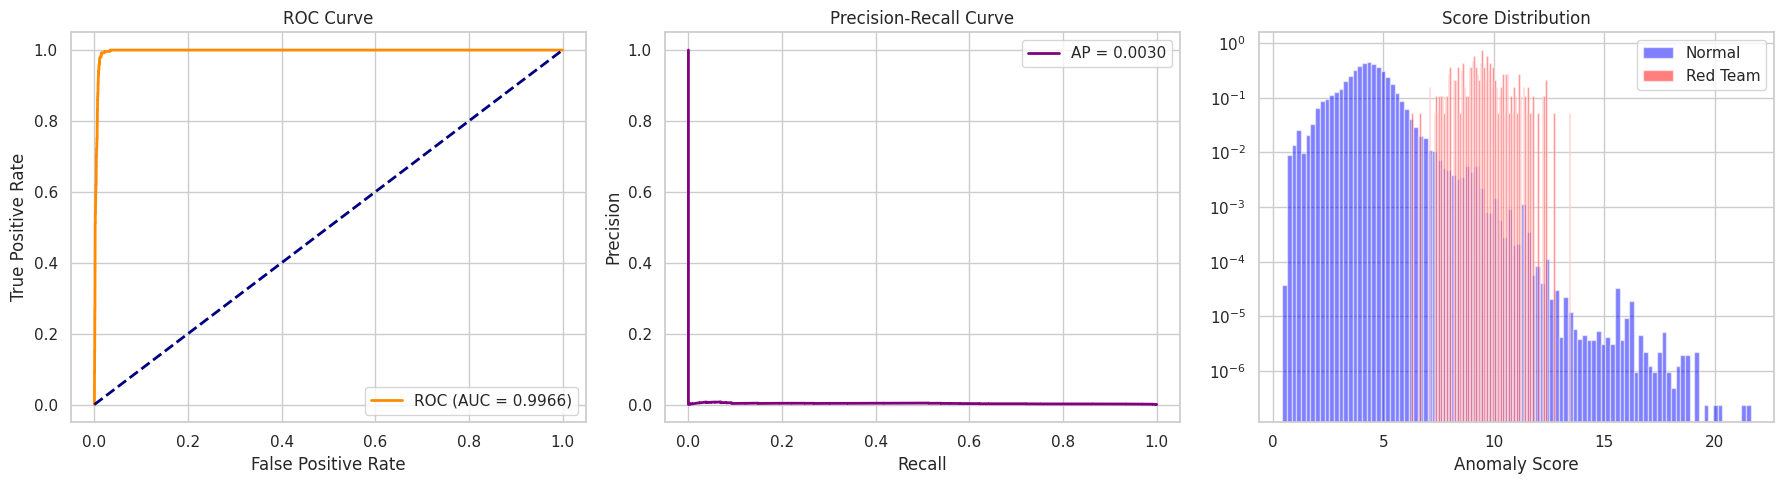

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

print("\n=== PAPER METRICS ===")
roc_auc = roc_auc_score(true_labels, anomaly_scores)
ap_score = average_precision_score(true_labels, anomaly_scores)
fpr, tpr, thresholds = roc_curve(true_labels, anomaly_scores)

recall_100_indices = np.where(tpr >= 1.0)[0]
specificity_at_100_recall = 1 - fpr[recall_100_indices[0]] if len(recall_100_indices) > 0 else 0.0

print(f"ROC AUC:                     {roc_auc:.4f}")
print(f"Average Precision (AP):      {ap_score:.4f}")
print(f"Specificity at 100% Recall:  {specificity_at_100_recall:.4f}")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

precision, recall, _ = precision_recall_curve(true_labels, anomaly_scores)
axes[1].plot(recall, precision, color='purple', lw=2, label=f'AP = {ap_score:.4f}')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

axes[2].hist(anomaly_scores[true_labels == 0], bins=100, alpha=0.5, color='blue', label='Normal', density=True)
axes[2].hist(anomaly_scores[true_labels == 1], bins=100, alpha=0.5, color='red', label='Red Team', density=True)
axes[2].set_title('Score Distribution')
axes[2].set_xlabel('Anomaly Score')
axes[2].set_yscale('log')
axes[2].legend()

plt.tight_layout()
plt.show()

- The model can rank attacks above normals well (high AUC), but operational precision remains challenging at full recall.

## SOC-Oriented Threshold Analysis

This final section converts scores into alert/no-alert decisions:
- Select threshold at the first ROC point with 100% recall (no missed attacks).
- Evaluate confusion matrix and classification report at that threshold.

Results:
- Threshold: `6.2625`.
- Missed attacks: `0`.
- False positives: `646,980`.

Insights:
- The detector can preserve full attack capture, but analyst load is high due to many false alarms.

=== OPERATIONAL SOC PERFORMANCE ===
Selected Anomaly Threshold: 6.2625 (Guarantees 100% Recall / 0 False Negatives)

--- Classification Report ---
              precision    recall  f1-score   support

  Normal (0)     1.0000    0.9666    0.9830  19374427
Red Team (1)     0.0004    1.0000    0.0008       261

    accuracy                         0.9666  19374688
   macro avg     0.5002    0.9833    0.4919  19374688
weighted avg     1.0000    0.9666    0.9830  19374688



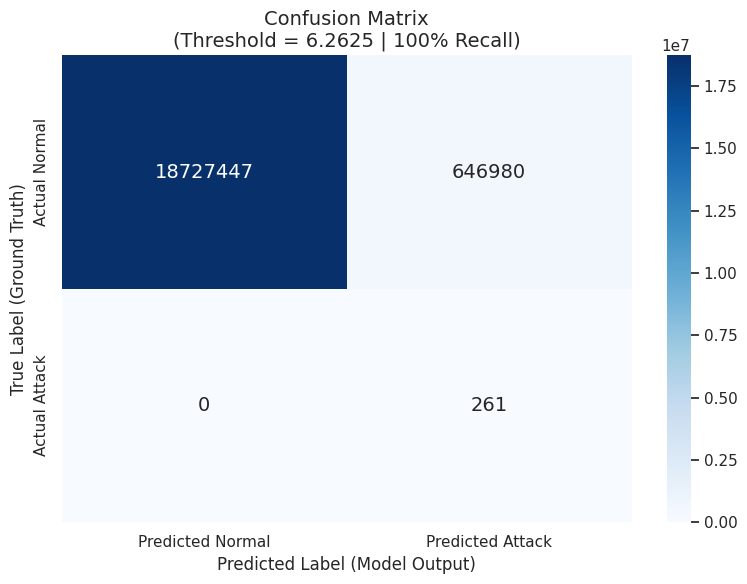


--- SOC Filtering Summary ---
Total Normal Events Filtered Out:  18,727,447 (Model successfully ignored these)
False Alarms Sent to SOC Analysts: 646,980 (These require manual review)
Red Team Attacks Caught:           261 (100% Success)
Red Team Attacks Missed:           0 (0% Failure)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("OPERATIONAL SOC PERFORMANCE")

# The paper focuses on filtering capability while keeping ALL attacks.
# We find the exact threshold that achieves 100% Recall (TPR >= 1.0)
recall_100_indices = np.where(tpr >= 1.0)[0]
if len(recall_100_indices) > 0:
    chosen_threshold = thresholds[recall_100_indices[0]]
else:
    chosen_threshold = thresholds[np.argmax(tpr)] # Fallback

print(f"Selected Anomaly Threshold: {chosen_threshold:.4f} (Guarantees 100% Recall / 0 False Negatives)")

# Generate discrete predictions (0 or 1) based on the threshold
y_pred = (anomaly_scores >= chosen_threshold).astype(int)

# 1. Print Classification Report
print("\n--- Classification Report ---")
# Using digits=4 to show the precision accurately despite the massive class imbalance
print(classification_report(true_labels, y_pred, target_names=['Normal (0)', 'Red Team (1)'], digits=4))

# 2. Plot Confusion Matrix
cm = confusion_matrix(true_labels, y_pred)

plt.figure(figsize=(8, 6))
# fmt='d' ensures it prints the exact whole numbers (not scientific notation)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Normal', 'Predicted Attack'],
            yticklabels=['Actual Normal', 'Actual Attack'],
            annot_kws={"size": 14})

plt.title(f'Confusion Matrix\n(Threshold = {chosen_threshold:.4f} | 100% Recall)', fontsize=14)
plt.ylabel('True Label (Ground Truth)', fontsize=12)
plt.xlabel('Predicted Label (Model Output)', fontsize=12)
plt.tight_layout()
plt.show()

# Quick text summary of what the matrix means:
true_negatives = cm[0][0]
false_positives = cm[0][1]
false_negatives = cm[1][0]
true_positives = cm[1][1]

print("\n--- SOC Filtering Summary ---")
print(f"Total Normal Events Filtered Out:  {true_negatives:,} (Model successfully ignored these)")
print(f"False Alarms Sent to SOC Analysts: {false_positives:,} (These require manual review)")
print(f"Red Team Attacks Caught:           {true_positives:,} (100% Success)")
print(f"Red Team Attacks Missed:           {false_negatives:,} (0% Failure)")